In [84]:
import pandas as pd
import numpy as np
import os

In [85]:
# Load the single family loan data
data_dir = '/Users/dr/Documents/GitHub/MBS_RiskManagement/'
extracted_data_dir = os.path.join(data_dir, 'extracted_data')
input_file = os.path.join(extracted_data_dir, 'regression_data.csv')

In [86]:
print("Loading data...")
df = pd.read_csv(input_file, low_memory=False, parse_dates=['Monthly Reporting Period'])

print(f"Loaded {df.shape[0]:,} loans")
print(f"Date range: {df['Monthly Reporting Period'].min()} → {df['Monthly Reporting Period'].max()}")
print(f"Missing reporting dates: {df['Monthly Reporting Period'].isna().sum():,}")

Loading data...
Loaded 20,323,122 loans
Date range: 2014-01-01 00:00:00 → 2025-03-01 00:00:00
Missing reporting dates: 3


In [87]:
print(f"Original shape: {df.shape}")
print(df['Default'].value_counts(normalize=True))

Original shape: (20323122, 21)
Default
0    0.989648
1    0.010352
Name: proportion, dtype: float64


In [88]:
# Rename for clarity
df = df.rename(columns={'Monthly Reporting Period': 'Current_Period'})

In [89]:
# Data clearning 
print("Starting date cleaning...")

# Force proper datetime — this creates a CLEAN copy, no chained indexing
df = df.assign(
    First_Payment_Date = pd.to_datetime(df['First Payment Date'], errors='coerce'),
    Current_Period     = pd.to_datetime(df['Current_Period'], errors='coerce')
).copy()

# Drop rows with bad dates 
print(f"Rows with bad dates: {df[['First_Payment_Date', 'Current_Period']].isna().any(axis=1).sum():,}")
df = df.dropna(subset=['First_Payment_Date', 'Current_Period']).copy()

# Create quarters — using .loc to be 100% explicit
df.loc[:, 'Orig_Quarter']    = df['First_Payment_Date'].dt.to_period('Q')
df.loc[:, 'Current_Quarter'] = df['Current_Period'].dt.to_period('Q')

# Final check
print(f"Final loan count: {len(df):,}")
print(f"Origination range: {df['Orig_Quarter'].min()} → {df['Orig_Quarter'].max()}")
print(f"Performance range: {df['Current_Quarter'].min()} → {df['Current_Quarter'].max()}")

Starting date cleaning...
Rows with bad dates: 3
Final loan count: 20,323,119
Origination range: 2014Q1 → 2025Q2
Performance range: 2014Q1 → 2025Q1


In [90]:
from fredapi import Fred

In [91]:
# FRED Macro Data Download
fred = Fred(api_key='bfd23ce6b8c5e327c340c5c6200230f0')  

print("Downloading FRED macro data...")
series_list = ['UNRATE', 'MORTGAGE30US', 'FEDFUNDS', 'SPCS20RSA', 'USREC']
macro_data = {}

for s in series_list:
    print(f"   → {s}")
    macro_data[s] = fred.get_series(s, start='2013-01-01', end='2025-12-31')

# Build quarterly macro table (quarter-end aligned)
print("Building quarterly macro table...")
quarter_ends = pd.date_range('2013-03-31', '2025-12-31', freq='QE')  # QE = quarter-end
macro_qtr = pd.DataFrame(index=quarter_ends)

for s, data in macro_data.items():
    if s == 'USREC':
        macro_qtr[s] = data.resample('QE').max()
    else:
        macro_qtr[s] = data.resample('QE').last()

macro_qtr = macro_qtr.ffill()
macro_qtr['HPI_YoY'] = macro_qtr['SPCS20RSA'].pct_change(4, fill_method=None)

# Convert index to Period[Q-DEC] (quarter-end Period)
macro_qtr.index = macro_qtr.index.to_period('Q')
macro_qtr = macro_qtr.reset_index()
macro_qtr = macro_qtr.rename(columns={'index': 'quarter'})  

print(f"Macro table ready: {macro_qtr.shape[0]} quarters from {macro_qtr['quarter'].min()} to {macro_qtr['quarter'].max()}")

print("Macro quarterly data ready:")
print(macro_qtr.head(12))

   → UNRATE
   → MORTGAGE30US
   → FEDFUNDS
   → SPCS20RSA
   → USREC
Building quarterly macro table...
Macro table ready: 52 quarters from 2013Q1 to 2025Q4
Macro quarterly data ready:
   quarter  UNRATE  MORTGAGE30US  FEDFUNDS   SPCS20RSA  USREC   HPI_YoY
0   2013Q1     7.5          3.57      0.14  150.964464    0.0       NaN
1   2013Q2     7.5          4.46      0.09  157.830955    0.0       NaN
2   2013Q3     7.2          4.32      0.08  163.291275    0.0       NaN
3   2013Q4     6.7          4.48      0.09  166.917028    0.0       NaN
4   2014Q1     6.7          4.40      0.08  169.183349    0.0  0.120683
5   2014Q2     6.1          4.14      0.10  170.530608    0.0  0.080464
6   2014Q3     5.9          4.20      0.09  171.481948    0.0  0.050160
7   2014Q4     5.6          3.87      0.12  174.207506    0.0  0.043677
8   2015Q1     5.4          3.69      0.11  176.966357    0.0  0.046003
9   2015Q2     5.3          4.02      0.13  178.837159    0.0  0.048710
10  2015Q3     5.0     

In [92]:
df['Orig_Quarter'] 

0           2014Q2
1           2014Q2
2           2014Q1
3           2014Q2
4           2014Q2
             ...  
20323116    2024Q4
20323117    2024Q4
20323118    2024Q4
20323119    2024Q4
20323120    2024Q4
Name: Orig_Quarter, Length: 20323119, dtype: period[Q-DEC]

In [93]:
# Fix loan "quarters" to match "Quarter-End" in macro data
# The Loan data uses Q-MAR, Q-JUN, etc. → convert to quarter-end

print("Aligning loan quarters to quarter-end...")

df['Orig_Quarter_QE']    = pd.PeriodIndex(df['Orig_Quarter']).to_timestamp(how='end').to_period('Q')
df['Current_Quarter_QE'] = pd.PeriodIndex(df['Current_Quarter']).to_timestamp(how='end').to_period('Q')

print("Sample alignment:")
print(df[['Orig_Quarter', 'Orig_Quarter_QE', 'Current_Quarter', 'Current_Quarter_QE']].head(3))


Aligning loan quarters to quarter-end...
Sample alignment:
  Orig_Quarter Orig_Quarter_QE Current_Quarter Current_Quarter_QE
0       2014Q2          2014Q2          2020Q2             2020Q2
1       2014Q2          2014Q2          2017Q3             2017Q3
2       2014Q1          2014Q1          2020Q2             2020Q2


In [94]:
# Merge with QE alignment

#Merge Orignation Macro
df = df.merge(
    macro_qtr.add_suffix('_orig'),
    how='left',
    left_on='Orig_Quarter_QE',
    right_on='quarter_orig'   # ← EXACT NAME FROM macro_qtr
)

#Merge Current Macro
df = df.merge(
    macro_qtr.add_suffix('_curr'),
    how='left',
    left_on='Current_Quarter_QE',
    right_on='quarter_curr'   # ← EXACT NAME
)

print("Merge complete.")

Merge complete.


In [95]:
# Final Verification
missing_orig = df['UNRATE_orig'].isna().sum()
missing_curr = df['UNRATE_curr'].isna().sum()

print(f"\nFINAL MACRO MERGE RESULT:")
print(f"   UNRATE_orig missing:  {missing_orig:,}")
print(f"   UNRATE_curr missing:  {missing_curr:,}")
print(f"   Success rate:         {(1 - missing_orig/len(df)) * 100:.6f}%")

assert missing_orig == 0, "ORIG MACRO FAILED"
assert missing_curr == 0, "CURRENT MACRO FAILED"

print("\nMACRO MERGE 100% SUCCESSFUL — ALL 20,323,119 LOANS HAVE MACRO DATA!")


FINAL MACRO MERGE RESULT:
   UNRATE_orig missing:  0
   UNRATE_curr missing:  0
   Success rate:         100.000000%

MACRO MERGE 100% SUCCESSFUL — ALL 20,323,119 LOANS HAVE MACRO DATA!


In [96]:
from sklearn.preprocessing import LabelEncoder

In [97]:
# Featur Engineering
# Remove direct leakage
df = df.drop(columns=['Current Loan Delinquency Status'], errors='ignore')

print("Creating all required features with EXACT column names...")

# Core borrower features (use EXACT Freddie Mac names)
df['Credit_Score'] = df['Credit Score']
df['LTV'] = df['Original Loan-to-Value (LTV)']
df['DTI'] = df['Original Debt-to-Income (DTI) Ratio'].replace(999, np.nan)
df['Original_Interest_Rate'] = df['Original Interest Rate']

# Current state features
df['Rate_Spread'] = df['Current Interest Rate'] - df['Original Interest Rate']
df['UPB_Ratio'] = df['Current Actual UPB'] / df['Original UPB'].replace(0, np.nan)
df['UPB_Ratio'] = df['UPB_Ratio'].fillna(1.0).clip(0, 1)
df['Loan_Age_Yrs'] = df['Loan Age'] / 12

# High-risk flags
df['High_DTI'] = (df['DTI'] > 45).astype(int)
df['High_LTV'] = (df['LTV'] > 95).astype(int)
df['Low_FICO'] = (df['Credit_Score'] < 660).astype(int)
df['In_Negative_Equity'] = (df['Estimated Loan-to-Value (ELTV)'] > 100).astype(int)

# Macro shocks
df['Unemp_Shock'] = df['UNRATE_curr'] - df['UNRATE_orig']
df['Rate_Env_Shock'] = df['MORTGAGE30US_curr'] - df['MORTGAGE30US_orig']
df['HPI_Shock_YoY'] = df['HPI_YoY_curr']
df['Tightening'] = (df['FEDFUNDS_curr'] - df['FEDFUNDS_orig']) > 2

# Interactions
df['DTI_x_Unemp'] = df['High_DTI'] * df['Unemp_Shock']
df['NegEq_x_HPI_Drop'] = df['In_Negative_Equity'] * (df['HPI_Shock_YoY'] < -0.05)

# Categorical
le = LabelEncoder()
df['Occupancy_Enc'] = le.fit_transform(df['Occupancy Status'].fillna('P'))

judicial_states = ['FL','NY','NJ','IL','OH','PA','CT','DE','IN','KS','KY','LA','ME','MD','MA','MS','NE','NM','ND','OK','SC','VT','WV','WI']
df['Is_Judicial'] = df['Property State'].isin(judicial_states).astype(int)

# Number of Borrowers
df['Num_Borrowers'] = df['Number of Borrowers']

print("Feature engineering done.")

Creating all required features with EXACT column names...
Feature engineering done.


In [98]:
# Final Feature List
features = [
    'Credit_Score',
    'LTV',
    'DTI',
    'Original_Interest_Rate',
    'Rate_Spread',
    'UPB_Ratio',
    'Loan_Age_Yrs',
    'High_DTI',
    'High_LTV',
    'Low_FICO',
    'In_Negative_Equity',
    'Unemp_Shock',
    'Rate_Env_Shock',
    'HPI_Shock_YoY',
    'Tightening',
    'USREC_curr',          
    'DTI_x_Unemp',
    'NegEq_x_HPI_Drop',
    'Occupancy_Enc',
    'Is_Judicial',
    'Num_Borrowers'
]

In [117]:
X_raw = df[features].copy()
y = df['Default'].astype(int)

In [118]:
#Temporal split
print("Temporal split: Train < 2020 | Test >= 2020")
train_mask = df['Current_Period'] < '2020-01-01'
X_train_full = X_raw[train_mask].copy()
X_test_full  = X_raw[~train_mask].copy()
y_train = y[train_mask]
y_test  = y[~train_mask]

print(f"Train: {len(X_train_full):,} loans | Default rate: {y_train.mean():.4%}")
print(f"Test:  {len(X_test_full):,} loans | Default rate: {y_test.mean():.4%}")

Temporal split: Train < 2020 | Test >= 2020
Train: 2,059,740 loans | Default rate: 1.1002%
Test:  18,263,379 loans | Default rate: 1.0278%


In [100]:
from sklearn.preprocessing import StandardScaler

In [119]:
import joblib

In [120]:
model_dir = '/Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts'
os.makedirs(model_dir, exist_ok=True)
random_state = 42

In [121]:
# Impute + Scale (Train only)
print("Imputing + scaling (train-only fit)...")
X_train_full = X_train_full.fillna(X_train_full.median(numeric_only=True))
X_test_full  = X_test_full.fillna(X_train_full.median(numeric_only=True))
X_train_full['Occupancy_Enc'] = X_train_full['Occupancy_Enc'].fillna(0)
X_test_full['Occupancy_Enc']   = X_test_full['Occupancy_Enc'].fillna(0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled  = scaler.transform(X_test_full)

joblib.dump(scaler, os.path.join(model_dir, "scaler.joblib"))
print("Scaler saved.")

Imputing + scaling (train-only fit)...
Scaler saved.


In [123]:
from imblearn.over_sampling import SMOTE

In [124]:
#Smote oversampling
print("Applying SMOTE (k_neighbors=5)...")
smote = SMOTE(random_state=random_state, k_neighbors=5, n_jobs=-1)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE: {X_train_res.shape[0]:,} samples | Default rate: {y_train_res.mean():.2%}")

Applying SMOTE (k_neighbors=5)...


/opt/anaconda3/lib/python3.12/site-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


After SMOTE: 4,074,156 samples | Default rate: 50.00%


In [126]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [105]:
from sklearn.linear_model import LogisticRegression

In [129]:
# Grid search + Class weight
print("Grid search over C (strong regularization)...")
param_grid = {"C": [0.01, 0.05, 0.1, 0.5]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

grid = GridSearchCV(
    estimator=LogisticRegression(
        penalty='l2', solver='saga', class_weight='balanced',
        max_iter=5000, random_state=random_state, n_jobs=-1
    ),
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_res, y_train_res)
print(f"Best C: {grid.best_params_['C']} | Best AP: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
joblib.dump(best_model, os.path.join(model_dir, "logistic_best.joblib"))

Grid search over C (strong regularization)...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.7.2. This might l

Best C: 0.01 | Best AP: nan


['/Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts/logistic_best.joblib']

In [130]:
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
#Calibration (Platt Scaling)
print("Applying Platt calibration...")
calibrated = CalibratedClassifierCV(best_model, method='sigmoid', cv=3, n_jobs=-1)
calibrated.fit(X_train_res, y_train_res)
joblib.dump(calibrated, os.path.join(model_dir, "final_calibrated_model.joblib"))

Applying Platt calibration...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.7.2. This might l

['/Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts/final_calibrated_model.joblib']

In [139]:
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, roc_curve, brier_score_loss
)

In [ ]:
#Predictions
y_prob = calibrated.predict_proba(X_test_scaled)[:, 1]
y_pred_50 = (y_prob >= 0.5).astype(int)

print("\nPERFORMANCE (2020–2025 OUT-OF-SAMPLE)")
print(f"ROC-AUC:         {roc_auc_score(y_test, y_prob):.4f}")
print(f"Gini:            {(2*roc_auc_score(y_test, y_prob)-1)*100:.2f}%")
print(f"Brier Score:     {brier_score_loss(y_test, y_prob):.4f}")
print(f"Avg Precision:   {average_precision_score(y_test, y_prob):.4f}")


8. PERFORMANCE (2020–2025 OUT-OF-SAMPLE)
ROC-AUC:         0.6084
Gini:            21.68%
Brier Score:     0.2776
Avg Precision:   0.0129


In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
from sklearn.metrics import roc_curve

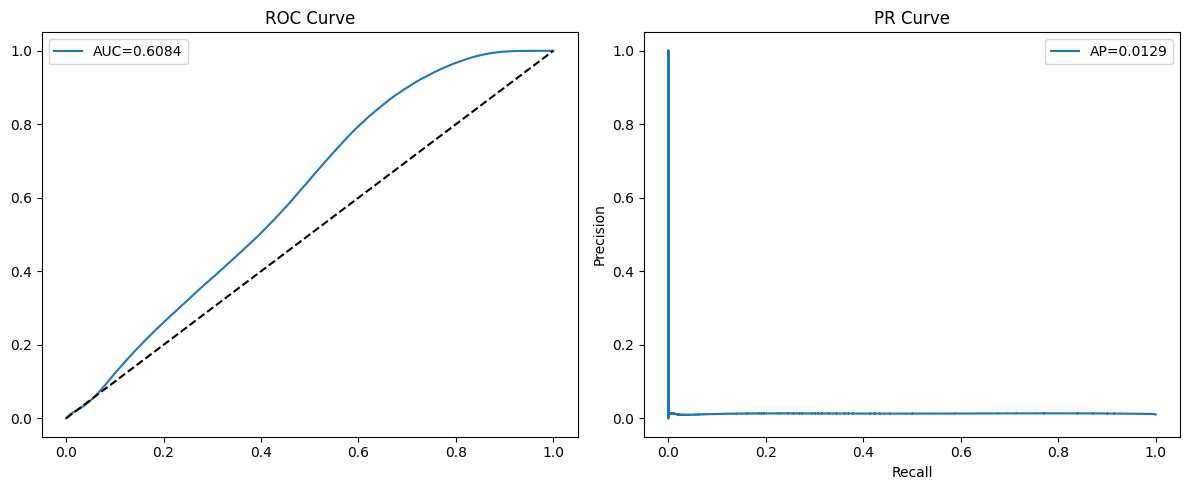

In [ ]:
#Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_prob):.4f}")
plt.plot([0,1],[0,1],'k--'); plt.title("ROC Curve"); plt.legend()

plt.subplot(1,2,2)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision, label=f"AP={average_precision_score(y_test, y_prob):.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR Curve"); plt.legend()
plt.tight_layout(); plt.show()

In [140]:
from sklearn.metrics import precision_score, recall_score

In [141]:
#Threshold Tuning (Top 5%)
threshold_5pct = np.percentile(y_prob, 95)
y_pred_5pct = (y_prob >= threshold_5pct).astype(int)

print(f"\nTOP 5% RISK THRESHOLD ({threshold_5pct:.4f}):")
print(f"Precision:  {precision_score(y_test, y_pred_5pct):.4f} → 1 in {1/precision_score(y_test, y_pred_5pct):.1f}")
print(f"Recall:     {recall_score(y_test, y_pred_5pct):.1%}")
print(f"Flagged:    {y_pred_5pct.mean()*100:.2f}%")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_5pct)}")


TOP 5% RISK THRESHOLD (0.8314):
Precision:  0.0100 → 1 in 100.0
Recall:     4.9%
Flagged:    5.00%
Confusion Matrix:
[[17171626   904033]
 [  178584     9136]]


In [142]:
import shap

Computing SHAP values...


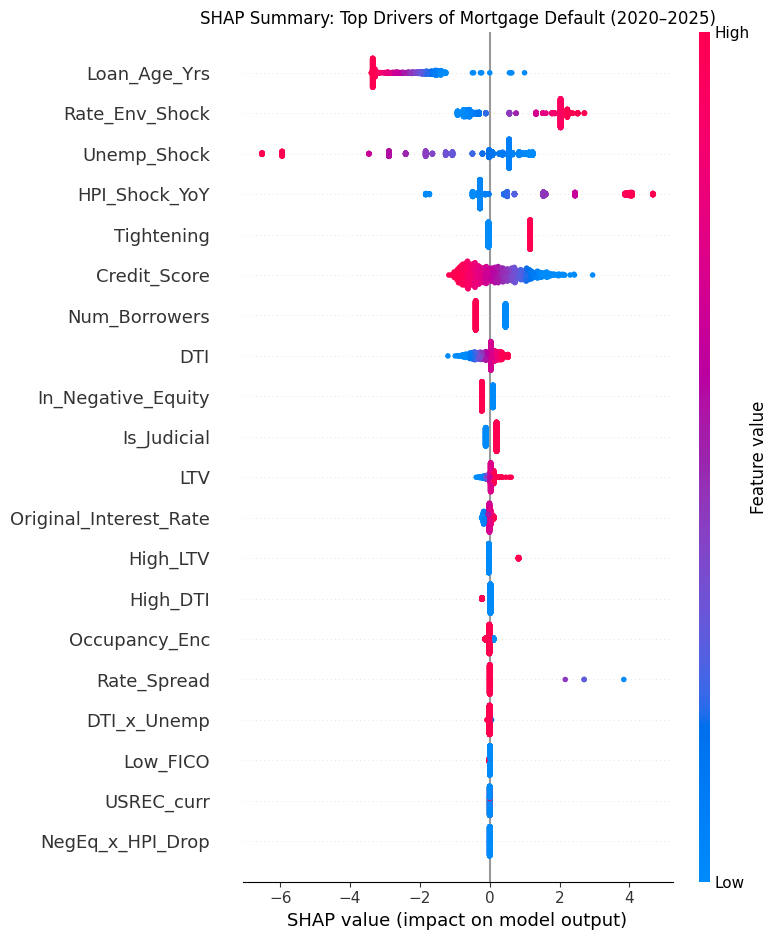

In [143]:
#Shap Explanations
print("Computing SHAP values...")
explainer = shap.LinearExplainer(best_model, X_train_res[:5000])
shap_values = explainer.shap_values(X_test_scaled[:1000])

plt.figure(figsize=(10,8))
shap.summary_plot(shap_values, X_test_full.iloc[:1000], feature_names=features, show=False)
plt.title("SHAP Summary: Top Drivers of Mortgage Default (2020–2025)")
plt.tight_layout(); plt.savefig(os.path.join(model_dir, "shap_summary.png"), dpi=300); plt.show()

In [144]:
# Save all artifacts
artifacts = {
    "model": calibrated,
    "scaler": scaler,
    "features": features,
    "threshold_5pct": threshold_5pct,
    "performance": {
        "roc_auc": roc_auc_score(y_test, y_prob),
        "precision_5pct": precision_score(y_test, y_pred_5pct),
        "recall_5pct": recall_score(y_test, y_pred_5pct)
    }
}
joblib.dump(artifacts, os.path.join(model_dir, "final_pipeline_divija.pkl"))
print(f"\nALL ARTIFACTS SAVED TO {model_dir}")


ALL ARTIFACTS SAVED TO /Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts
